# Idea

Get more insight into the active features, lags and coefficients.

## Naming Conventions with example:

Belong to X:
- Feature: *|avg B|* (refers to a measured physical parameter)
- Lag: *|avg B|_lag_1* (refers to all columns in X)

Belong to y:
- Target: *y_step_1*

Belong to the Model:
- Coefficient: each coefficient belongs to one Lag and a target

# Imports

In [1]:
import os
# os.nice(19)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
model_name = 'MultiTaskLassoCV'
model_No = 4
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Model

In [4]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/saved_models")
model = joblib.load(MODEL_DIR / f'{model_name}_{target}_model_{model_No}.pkl')
scaler = joblib.load(MODEL_DIR / f'{model_name}_{target}_scaler_{model_No}.pkl')

# Run Model

In [5]:
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

y_test_pred = pd.DataFrame(model.predict(X_test_scaled), index=X_test.index, columns=y_test.columns)

# Results

## Check Coefficients

In [6]:
coeff_all = model.coef_
print("Coefficient array shape:", coeff_all.shape)
coeff_matrix = pd.DataFrame(
    model.coef_,
    index=y_test.columns,
    columns=X_test.columns
)
print("Coefficient matrix shape:", coeff_matrix.shape)

Coefficient array shape: (48, 538)
Coefficient matrix shape: (48, 538)


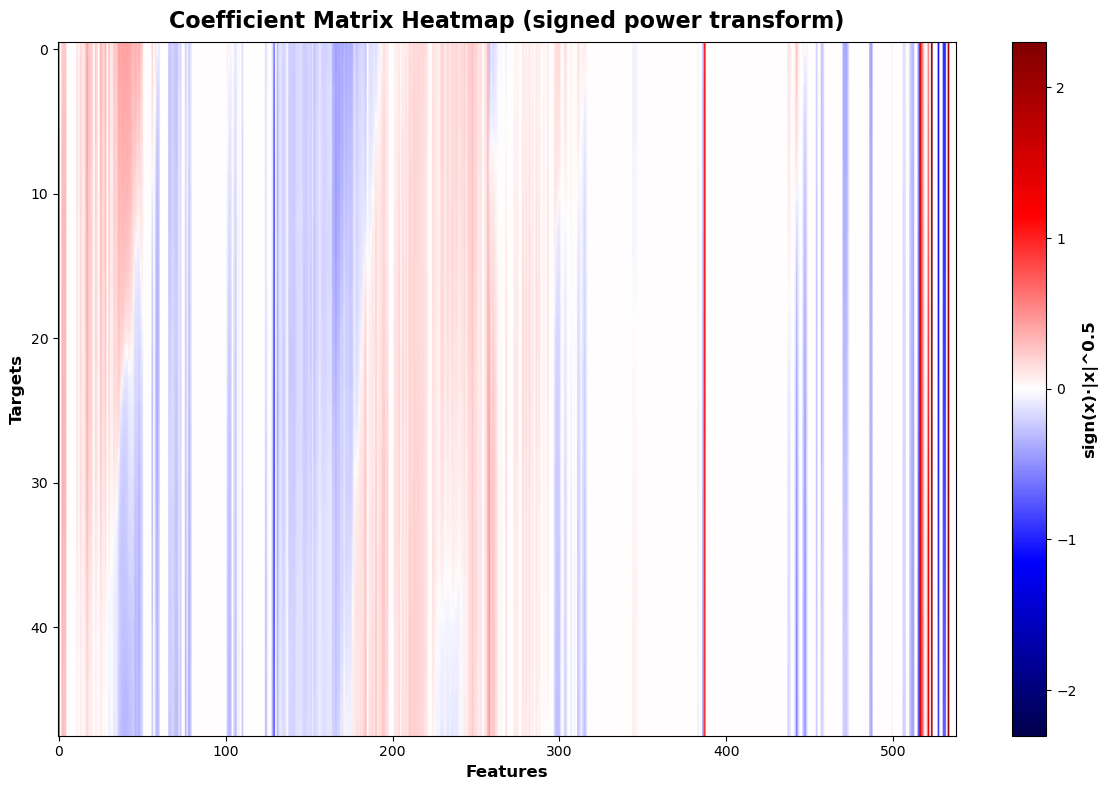

In [7]:
alpha = 0.5
coeff_transformed = np.sign(coeff_matrix) * np.abs(coeff_matrix) ** alpha

plt.figure(figsize=(12, 8))
plt.imshow(
    coeff_transformed,
    aspect='auto',
    cmap='seismic',
    vmin=-np.max(np.abs(coeff_transformed.values)),
    vmax=np.max(np.abs(coeff_transformed.values))
)
plt.colorbar(label=f'sign(x)·|x|^{alpha}')
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Coefficient Matrix Heatmap (signed power transform)')
plt.show()


# Statistics

In [ ]:
coeff_all = model.coef_

# Summary of active lags
active_lags = np.sum(np.any(coeff_all != 0, axis=0))
total_lags = coeff_all.shape[1]
print(f"Active Lags: {active_lags:3d}/{total_lags} ({(active_lags/total_lags)*100:.2f}%)")

lag_names = X_test.columns
lag_names = lag_names[np.any(coeff_all != 0, axis=0)]
features = lag_names.str.extract(r'^(.+?)_lag_')[0]
summary = (
    features
    .value_counts()
    .rename_axis('feature')
    .reset_index(name='n_columns')
)
print(f"{len(summary)} different features:")
for feature, k in summary.itertuples(index=False):
    print(f'    "{feature}": {k} lags,')

# Summary of active coefficients
active_coefs = np.sum(coeff_all != 0)
print(f"\nActive Coefficients: {active_coefs:3d}/{coeff_all.size} ({(active_coefs/coeff_all.size)*100:.2f}%)")
coef_names = X_test.columns[np.where(coeff_all != 0)[1]]
coef_features = coef_names.str.extract(r'^(.+?)_lag_')[0]
coef_summary = (
    coef_features
    .value_counts()
    .rename_axis('feature')
    .reset_index(name='n_coefficients')
)
print(f"{len(coef_summary)} different features with active coefficients:")
for feature, k in coef_summary.itertuples(index=False):
    print(f'    "{feature}": {k} coefficients,')

Active Lags: 270/538 (50.19%)
8 different features:
    "Bz GSE": 122 lags,
    "|avg B|": 68 lags,
    "Temperature (K)": 45 lags,
    "Flow Speed (km/s": 25 lags,
    "F10.7 (LASP)": 5 lags,
    "median_decay_last_7D": 2 lags,
    "median_decay_last_14D": 2 lags,
    "median_decay_last_30D": 1 lags,

Active Coefficients: 6253/25824 (24.21%)
7 different features with active coefficients:
    "Bz GSE": 3125 coefficients,
    "|avg B|": 1439 coefficients,
    "Temperature (K)": 1242 coefficients,
    "F10.7 (LASP)": 240 coefficients,
    "Flow Speed (km/s": 111 coefficients,
    "median_decay_last_7D": 48 coefficients,
    "median_decay_last_30D": 48 coefficients,


# Plots

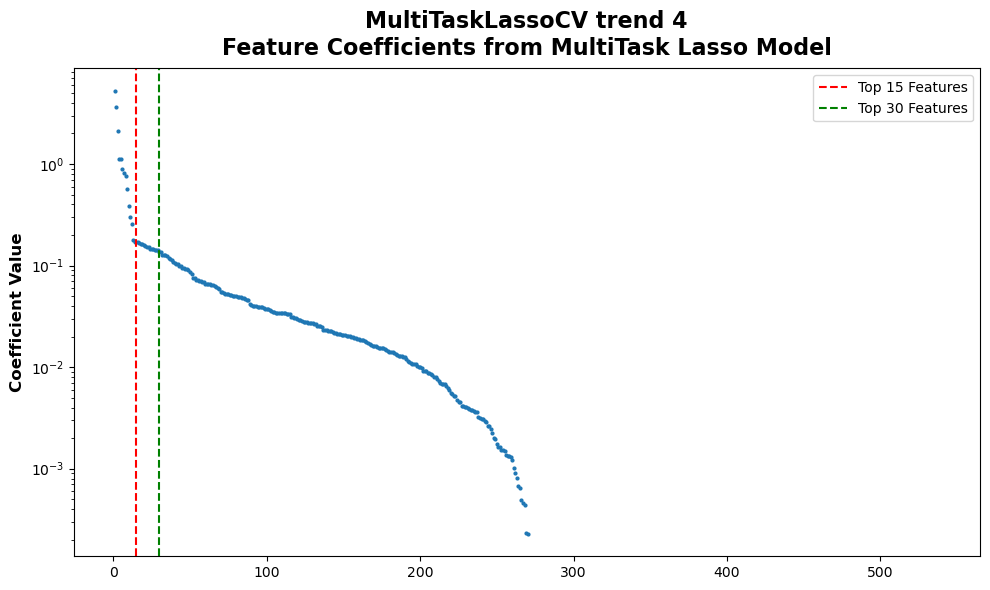

,feature,coefficient,lag_hours
523,median_decay_last_7D_lag_1,5.283343,0.08
533,median_decay_last_30D_lag_1,3.617486,0.08
516,F10.7 (LASP)_lag_1,2.116077,0.08
387,Flow Speed (km/s_lag_1,1.122584,0.08
527,median_decay_last_7D_lag_577,-1.121267,48.08
531,median_decay_last_14D_lag_433,-0.889448,36.08
530,median_decay_last_14D_lag_289,-0.812137,24.08
0,|avg B|_lag_1,0.764762,0.08
517,F10.7 (LASP)_lag_73,0.570241,6.08
129,Bz GSE_lag_1,-0.383656,0.08


In [9]:
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()

coef_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient': model.coef_[1, :]
})
coef_df = coef_df.sort_values(by='coefficient', key=abs, ascending=False)
coef_df['lag_hours'] = coef_df['feature'].apply(lambda x: f"{int(x.split('_')[-1]) * (dt_seconds / 3600):.2f}" if 'lag' in x else np.nan)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(range(1,len(coef_df)+1), abs(coef_df['coefficient']), s = 4)
ax.axvline(x=15, color='red', linestyle='--', label='Top 15 Features')
ax.axvline(x=30, color='green', linestyle='--', label='Top 30 Features')
ax.set_ylabel('Coefficient Value')
ax.set_title(f'{model_name} {target} {model_No}\nFeature Coefficients from MultiTask Lasso Model')
ax.set_yscale('log')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

coef_df.head(10)

## Plot coefficient stability

In [10]:
coef_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient_0': model.coef_[0, :],
    'coefficient_n': model.coef_[-1, :],
    'coefficient_mean': model.coef_.mean(axis=0),
    'coefficient_std': model.coef_.std(axis=0),
    'coefficient_max': model.coef_.max(axis=0),
    'coefficient_min': model.coef_.min(axis=0)
})

stepsize = 5 / 60 # in hours
coef_df[["feature", "lag"]] = (
    coef_df["feature"]
    .str.extract(r"^(?P<feature_name>.+?)_lag_(?P<lag>\d+)$")
)
coef_df['lag_time'] = coef_df['lag'].astype(int) * stepsize

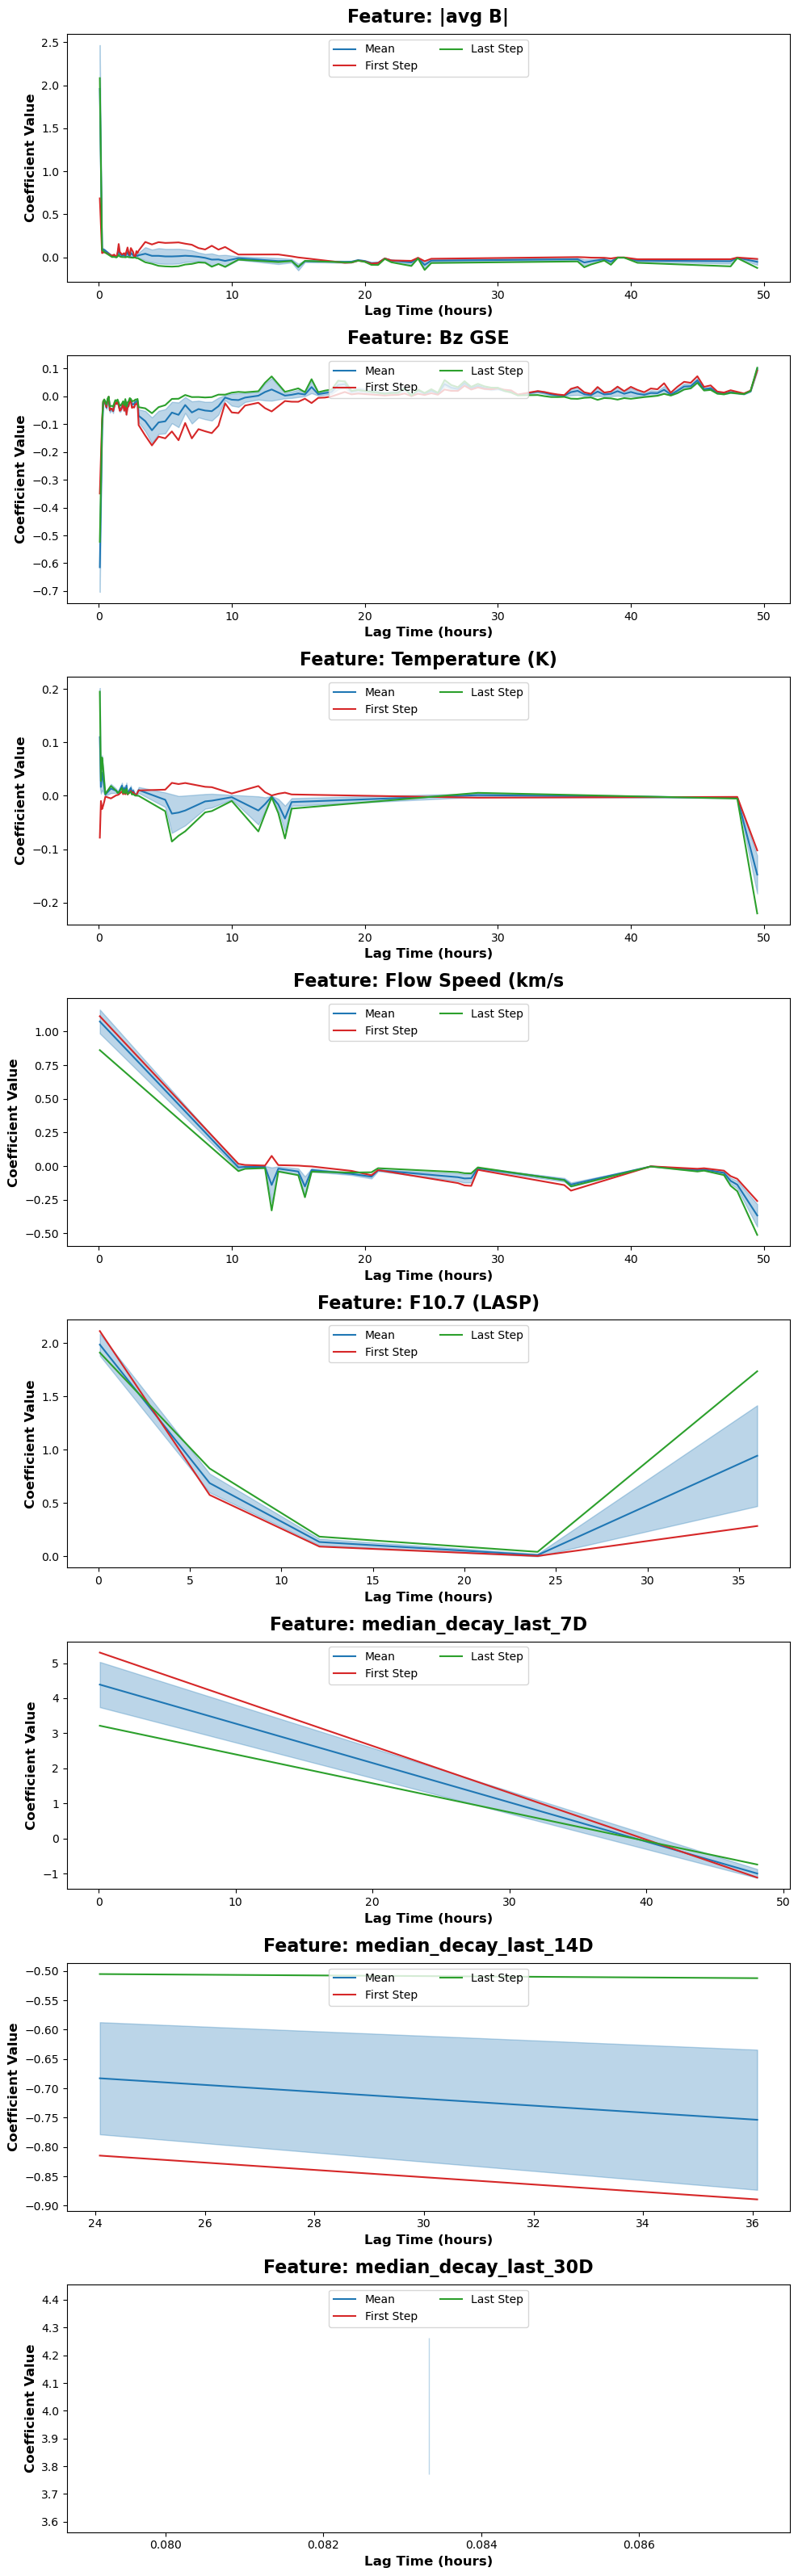

In [11]:

# unique features
unique_features = coef_df['feature'].unique()

fig, axs = plt.subplots(len(unique_features), 1, figsize=(10, 4 * len(unique_features)))
for i, feature in enumerate(unique_features):
    ax = axs[i] if len(unique_features) > 1 else axs
    feature_coefs = coef_df[coef_df['feature'] == feature]
    
    # only include coefficients where mean is bigger than 1e-3
    feature_coefs = feature_coefs[feature_coefs['coefficient_mean'].abs() > 1e-3]

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_mean'],
        color='tab:blue',
        ms=4,
        alpha = 1.0,
        label="Mean"
    )

    ax.fill_between(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_mean'] - feature_coefs['coefficient_std'],
        feature_coefs['coefficient_mean'] + feature_coefs['coefficient_std'],
        color='tab:blue',
        alpha=0.3,
    )

    # ax.plot(
    #     feature_coefs['lag_time'],
    #     feature_coefs['coefficient_max'],
    #     color='tab:red',
    #     ms=4,
    #     alpha = 1.0,
    #     label="Max"
    # )

    # ax.plot(
    #     feature_coefs['lag_time'],
    #     feature_coefs['coefficient_min'],
    #     color='tab:green',
    #     ms=4,
    #     alpha = 1.0,
    #     label="Min"
    # )

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_0'],
        color='tab:red',
        ms=4,
        alpha = 1.0,
        label="First Step"
    )

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_n'],
        color='tab:green',
        ms=4,
        alpha = 1.0,
        label="Last Step"
    )
    
    ax.set_title(f'Feature: {feature}')
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    # ax.set_xscale('log')
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()